<a href="https://colab.research.google.com/github/priyadarshinig15/mnist-digit-classifier/blob/main/mnist_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
!pip install tensorflow matplotlib

In [19]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

In [20]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()


In [21]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


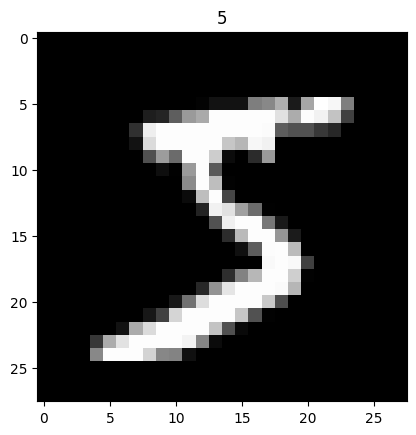

In [22]:
plt.imshow(x_train[0],cmap='gray')
plt.title(y_train[0])
plt.show()

### Normalisind the data (as CNN works better with value between 0 to 1)

In [23]:
x_train = x_train/255.0
x_test = x_test / 255.0

reshape the images as CNN expects **(hieght,width,channels)**


In [24]:
x_train = x_train.reshape((60000,28,28,1))
x_test = x_test.reshape((10000,28,28,1))

In [26]:
model = models.Sequential([
    layers.Conv2D(32,(3,3),activation='relu',input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D((2,2)),
    layers.Flatten(),
    layers.Dense(64,activation='relu'),
    layers.Dense(10,activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [27]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [28]:
history = model.fit(x_train,y_train,epochs=5,validation_data=(x_test,y_test))

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 66s 34ms/step - accuracy: 0.9534 - loss: 0.1522 - val_accuracy: 0.9840 - val_loss: 0.0515
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 31ms/step - accuracy: 0.9850 - loss: 0.0492 - val_accuracy: 0.9850 - val_loss: 0.0454
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9892 - loss: 0.0334 - val_accuracy: 0.9873 - val_loss: 0.0386
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 62s 33ms/step - accuracy: 0.9917 - loss: 0.0250 - val_accuracy: 0.9902 - val_loss: 0.0313
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 63s 34ms/step - accuracy: 0.9941 - loss: 0.0190 - val_accuracy: 0.9863 - val_loss: 0.0510


In [29]:
test_loss, test_acc = model.evaluate(x_test,y_test)
print(f"Test accuracy: {test_acc}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.9863 - loss: 0.0510
Test accuracy: 0.986299991607666


In [31]:
prediction = model.predict(x_test)
print(prediction[0].argmax())

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
7


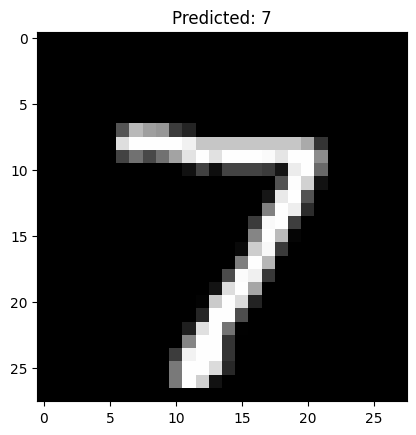

In [33]:
plt.imshow(x_test[0].reshape(28,28),cmap='gray')
plt.title(f"Predicted: {prediction[0].argmax()}")
plt.show()

In [34]:
model.save("Digit_recogniser_Model.h5")

In [36]:
from tensorflow.keras.models import load_model
model = load_model("Digit_recogniser_Model.h5")

In [37]:
prediction = model.predict(x_test)
predicted_digit = prediction[0].argmax()
print(f"Predicted digit: {predicted_digit}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step
Predicted digit: 7


<function matplotlib.pyplot.show(close=None, block=None)>

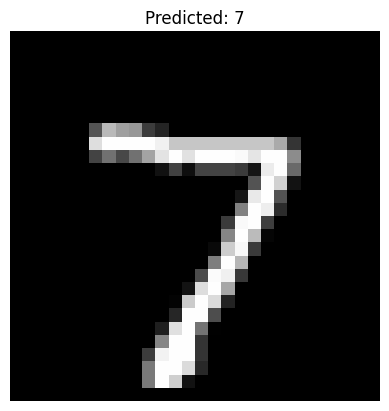

In [38]:
plt.imshow(x_test[0].reshape(28,28),cmap='gray')
plt.title(f"Predicted: {predicted_digit}")
plt.axis('off')
plt.show


In [40]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9863 - loss: 0.0510
Test Accuracy: 0.986299991607666


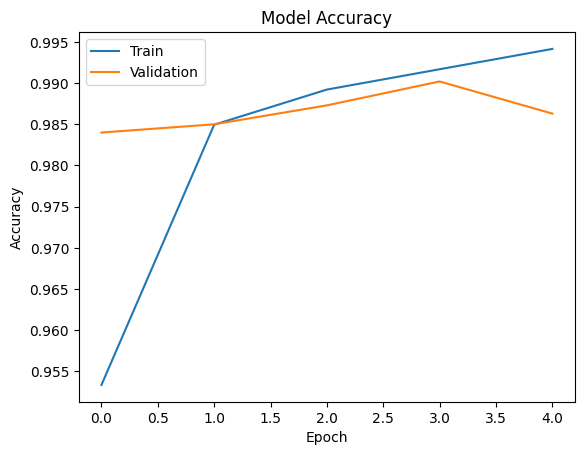

In [41]:
plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')

plt.ylabel('Accuracy')

plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])

plt.show()